### TF activity inference 

In [1]:
import pandas as pd
import numpy as np
import decoupler as dc
from anndata import AnnData
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from upsetplot import UpSet, from_contents
plt.rcParams['svg.fonttype'] = 'none'

/home/mmultari/miniconda3/envs/GRN/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First Import dataset and filter it to match the GRN

In [2]:
GRN = pd.read_csv('Data/Network_GRN_HIVE_curated.txt',sep='\t')
GRN.rename(columns={'tf.name':'source','target.name':'target'}, inplace=True)

In [3]:
Dataset = pd.read_csv('DEA/Merge_stat_all.tsv',index_col=0, sep='\t')

In [4]:
Dataset = Dataset.reset_index()
Dataset['OLN'] = Dataset['index'].str.extract(r'(Solyc\d+g\d+)')
Dataset = Dataset.rename(columns={'index':'Gene_Name'})
Dataset.columns=Dataset.columns.str.replace('stat_','', regex=False)
Dataset = Dataset.fillna(0)

In [5]:
filtered_dataset = Dataset[Dataset['OLN'].isin(GRN['source']) | Dataset['OLN'].isin(GRN['target'])]
filtered_dataset = filtered_dataset.set_index('OLN')

In [6]:
conditions = ['Pinfestans','Cfulvum','PSTVd_S23','PSTVd_M','Bcinerea','Mincognita_7dpi','Mincognita_14dpi']

In [7]:
matrix = filtered_dataset[conditions].T

In [8]:
tf_acts, tf_pvals = dc.run_ulm(mat=matrix, net=GRN, verbose=True, weight=None)

Running ulm on mat with 7 samples and 1786 targets for 68 sources.


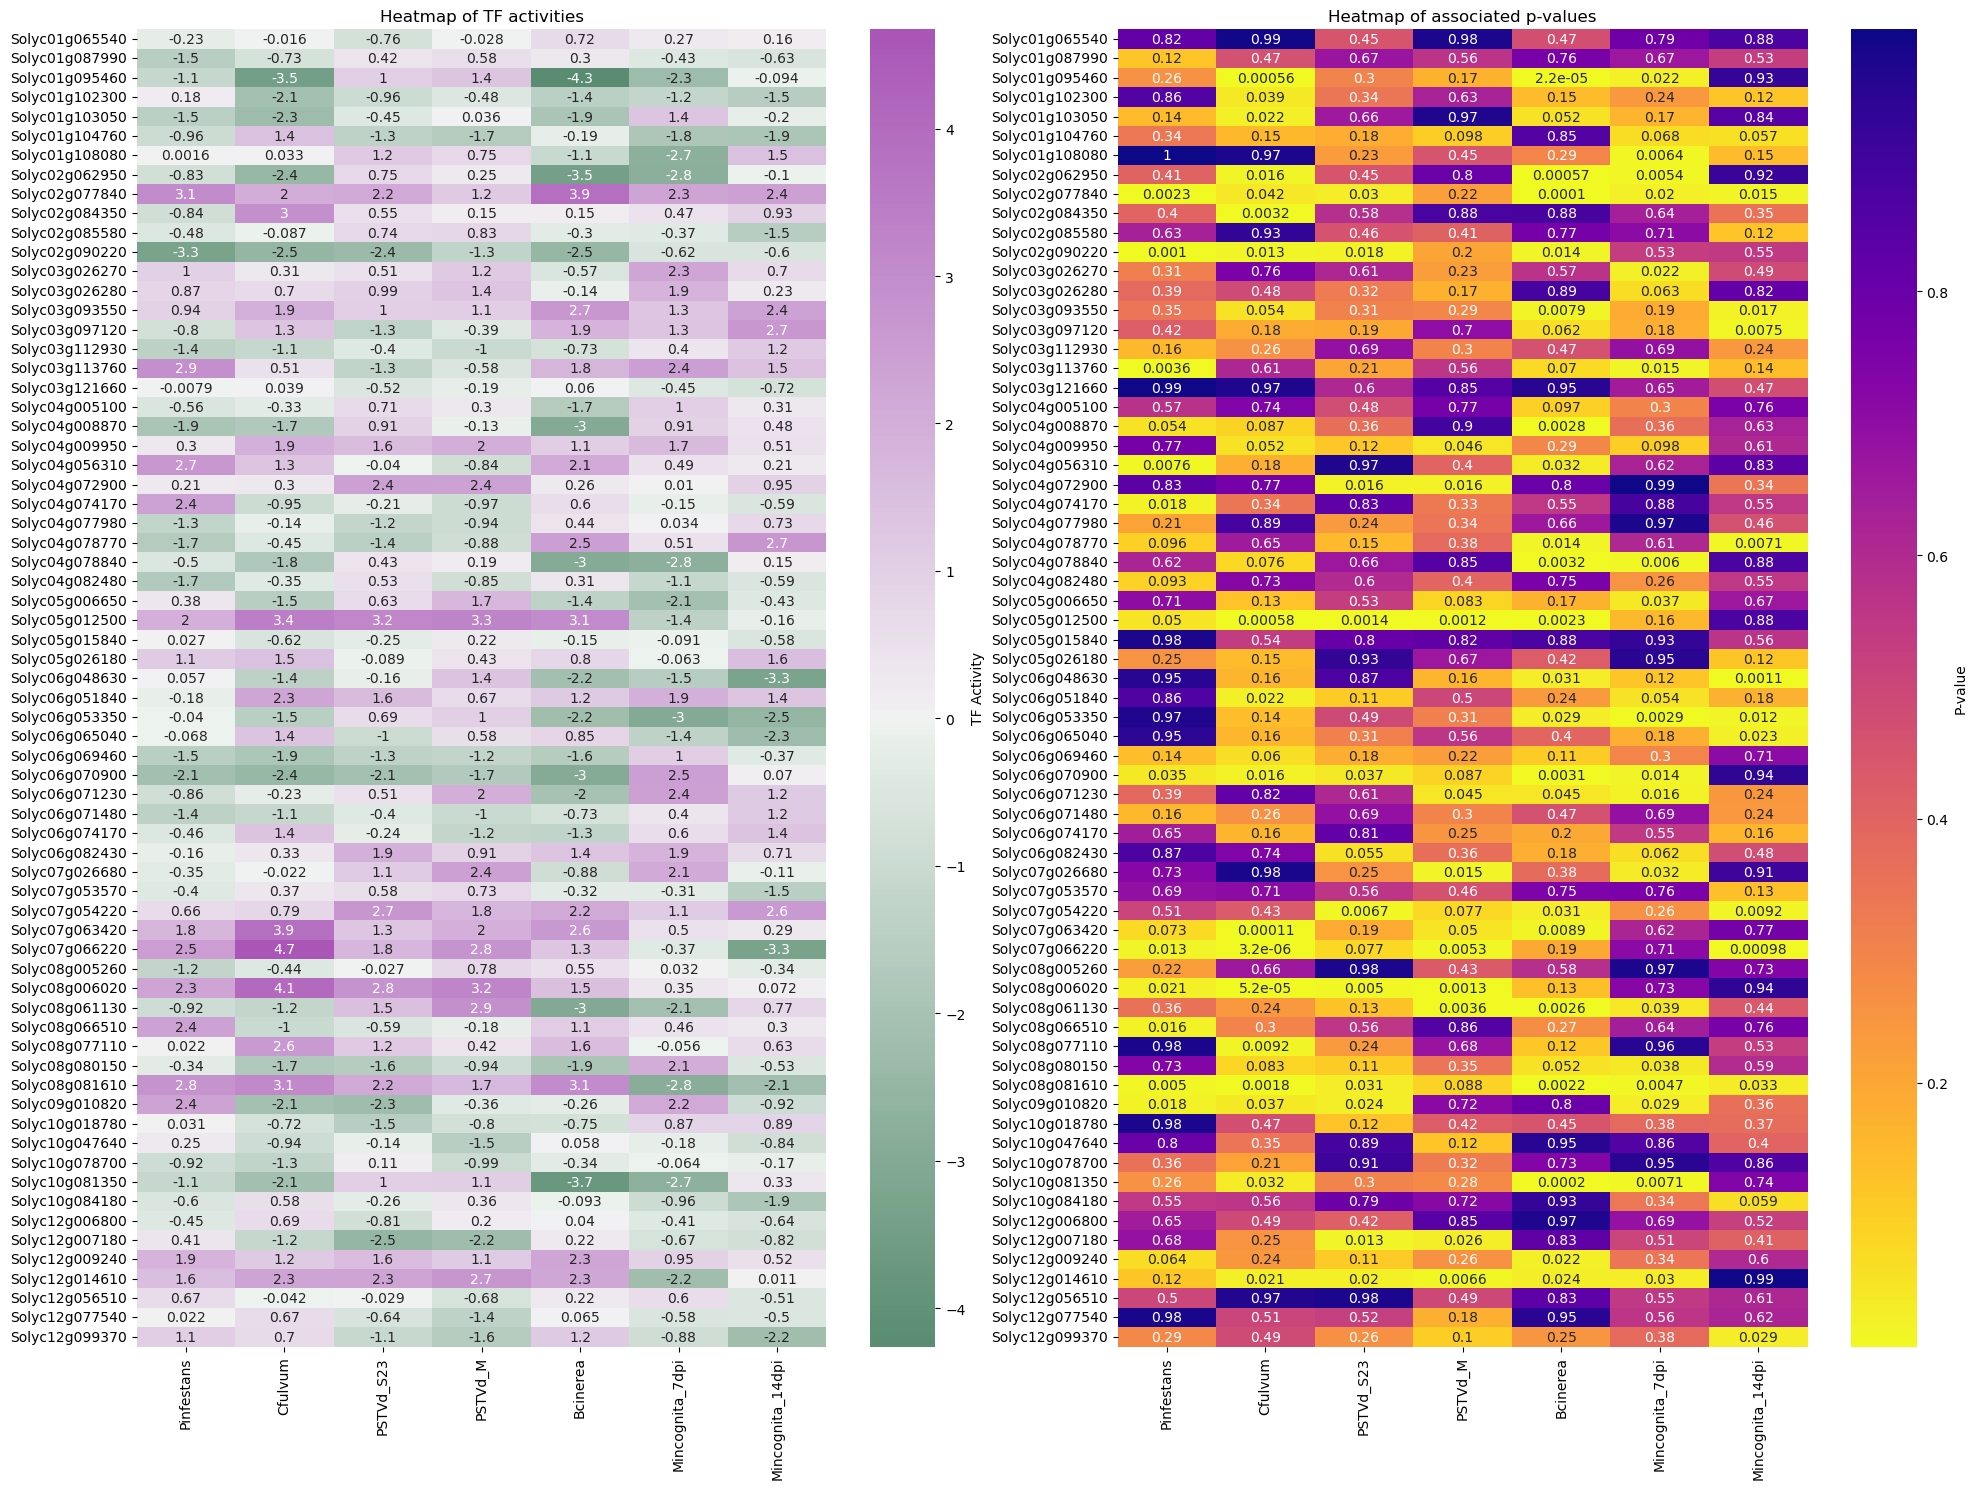

In [9]:
fig, axes = plt.subplots(1,2, figsize=(20,15), tight_layout=True)

axes[0].set_title('Heatmap of TF activities')
sns.heatmap(tf_acts.T, cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), ax=axes[0], center=0, annot=True, cbar_kws={'label': 'TF Activity'})
axes[1].set_title('Heatmap of associated p-values')
sns.heatmap(tf_pvals.T, cmap='plasma_r', ax=axes[1], annot=True,cbar_kws={'label': 'P-value'})
# plt.savefig('./Results/Plot/Heatmap_activity_TF_all.svg', format='svg')
plt.show()

In [10]:
pvals = tf_pvals.T
acts = tf_acts.T
significant_pvals = pvals[pvals[conditions].apply(lambda x: x <= 0.05, axis=1).any(axis=1)]
# new_column_names_pvals = {col: col + '_pval' for col in significant_pvals.columns}
# significant_pvals.rename(columns=new_column_names_pvals, inplace=True)
significant_acts = acts[acts.index.isin(significant_pvals.index)]
# new_column_names_acts = {col: col + '_acts' for col in significant_acts.columns}
# significant_acts.rename(columns=new_column_names_acts, inplace=True)

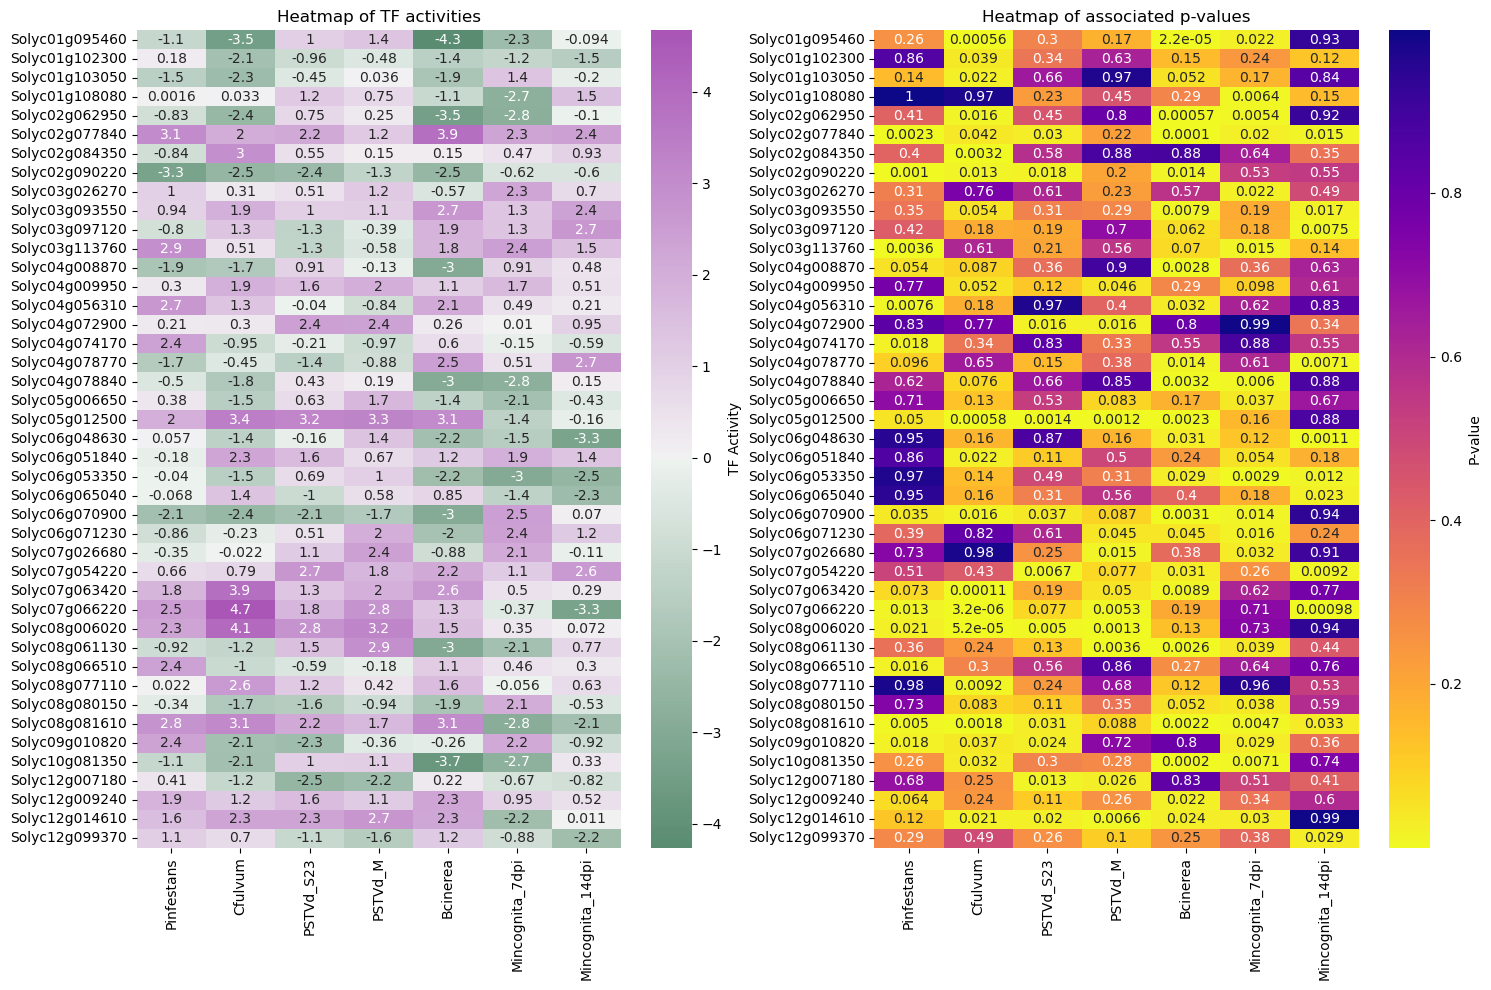

In [11]:
fig, axes = plt.subplots(1,2, figsize=(15,10), tight_layout=True)

axes[0].set_title('Heatmap of TF activities')
sns.heatmap(significant_acts, cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), ax=axes[0], center=0, annot=True, cbar_kws={'label': 'TF Activity'})
axes[1].set_title('Heatmap of associated p-values')
sns.heatmap(significant_pvals, cmap='plasma_r', ax=axes[1], annot=True,cbar_kws={'label': 'P-value'})
# plt.savefig('./Results/Plot/Heatmap_activity_signif_TF.svg', format='svg')
plt.show()

Export the results

In [16]:
pvals = tf_pvals.T
acts = tf_acts.T
# significant_pvals = pvals[pvals[conditions].apply(lambda x: x <= 0.05, axis=1).any(axis=1)]
new_column_names_pvals = {col: col + '_pval' for col in significant_pvals.columns}
pvals.rename(columns=new_column_names_pvals, inplace=True)
# significant_acts = acts[acts.index.isin(significant_pvals.index)]
new_column_names_acts = {col: col + '_acts' for col in significant_acts.columns}
acts.rename(columns=new_column_names_acts, inplace=True)

In [17]:
modified_df = filtered_dataset.copy()
modified_df.columns = [
    'stats_' + col if col in modified_df[conditions].columns else col
    for col in modified_df.columns
]

In [18]:
Tf_activity_res = pd.merge(acts, pvals, left_index=True, right_index=True)

In [19]:
def get_groups(row):
    groups = []
    cols = pvals.columns
    for col in cols:
        if row[col] <= 0.05:
            groups.append(col)
    return ' & '.join(groups) if groups else None

In [20]:
Tf_activity_res['Groups'] = Tf_activity_res.apply(get_groups, axis=1)

In [21]:
Expr_tf_activity = pd.merge(modified_df, Tf_activity_res, left_index=True, right_index=True, how='left')

In [22]:
info = pd.read_csv('Data/Network_GRN_HIVE_INFO.txt', sep='\t', index_col=0)

In [23]:
Results_merge = pd.merge(info, Expr_tf_activity, left_index=True, right_index=True)
Results_merge.index.name = 'OLN'

In [ ]:
# Results_merge.to_csv('Results_hubs_activity_stats.tsv',sep='\t',index=True)

In [24]:
Results_merge[Expr_tf_activity['Groups'].notnull()].shape


/tmp/ipykernel_32160/120994322.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Results_merge[Expr_tf_activity['Groups'].notnull()].shape


(43, 25)

----

---------

##### Pathway activity

Using Mercator to genes associations

In [25]:
def list_to_merc_f(gene_list, merc_res): 
    """
    This function will takes in input a gene list of interest and the mercator annotations (generally annotations on all the CDS of the 
    plant of interest) and will extract, from the annotations, only those related to the genes in the list 
    """
    hit_merc_res = merc_res[~(merc_res["IDENTIFIER"].isna())]
    pattern = "|".join(list(map(str.lower,gene_list))) # create a regex for str.contains for the different version of a gene .1, .2 etc...
    gene_hit = hit_merc_res[hit_merc_res["IDENTIFIER"].str.contains(pattern)]

    return gene_hit

In [52]:
mercator_res = pd.read_csv("Data/Mercator_annotation_Sly_4_1.txt", sep="\t", quotechar="'")
mercator_res["IDENTIFIER"]= mercator_res["IDENTIFIER"].str.split(".").str.get(0)

In [27]:
annot_target_grn=list_to_merc_f(GRN['target'].to_list(), mercator_res)
annot_target_grn['NAME'] = annot_target_grn['NAME'].str.split(".").str.get(0)
annot_target_grn['IDENTIFIER'] = annot_target_grn['IDENTIFIER'].str.capitalize()
annot_target_grn.rename(columns={"NAME": "ANNOT"}, inplace=True)
annot_target_grn=annot_target_grn[['IDENTIFIER','ANNOT']]
annot_remove_unassigned=annot_target_grn[annot_target_grn["ANNOT"] != 'not assigned']

In [28]:
network_pathway_mercator = annot_remove_unassigned.copy()
network_pathway_mercator.rename(columns={"IDENTIFIER": "target", "ANNOT":'source'}, inplace=True)
network_pathway_mercator=network_pathway_mercator.drop_duplicates()
network_pathway_mercator = network_pathway_mercator[network_pathway_mercator['target'].isin(matrix.columns)]

In [31]:
pathway_acts, pathway_pvals = dc.run_mlm(mat=matrix, net=network_pathway_mercator, verbose=True, weight=None)

Running mlm on mat with 7 samples and 1786 targets for 30 sources.


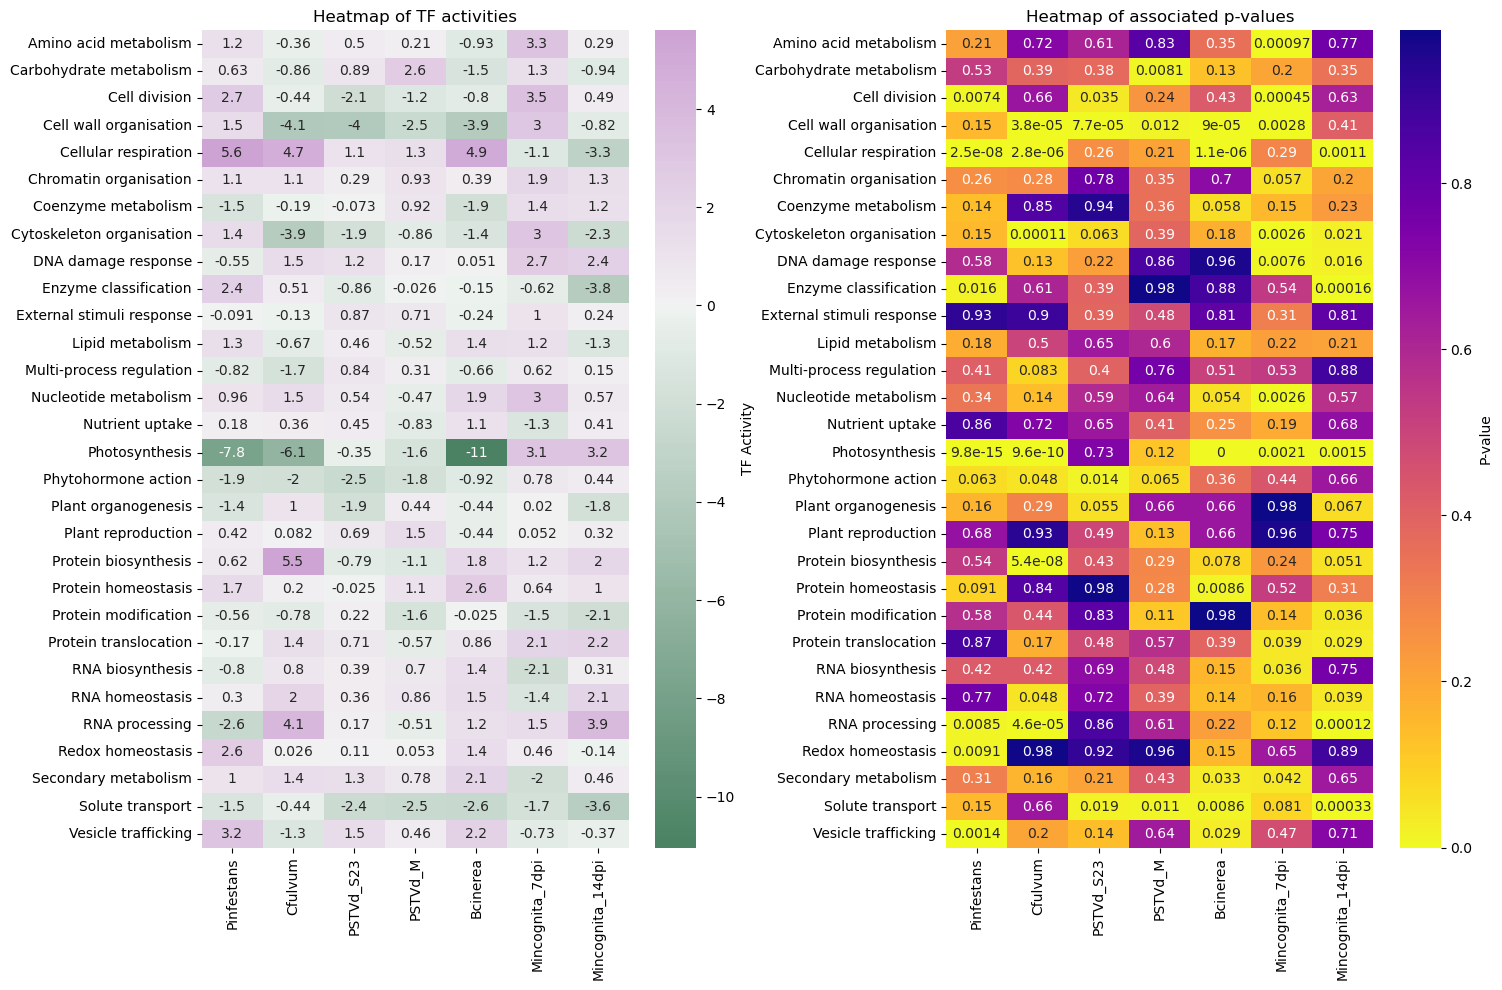

In [32]:
fig, axes = plt.subplots(1,2, figsize=(15,10), tight_layout=True)

axes[0].set_title('Heatmap of TF activities')
sns.heatmap(pathway_acts.T, cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), ax=axes[0], center=0, annot=True, cbar_kws={'label': 'TF Activity'})
axes[1].set_title('Heatmap of associated p-values')
sns.heatmap(pathway_pvals.T, cmap='plasma_r', ax=axes[1], annot=True,cbar_kws={'label': 'P-value'})

plt.show()

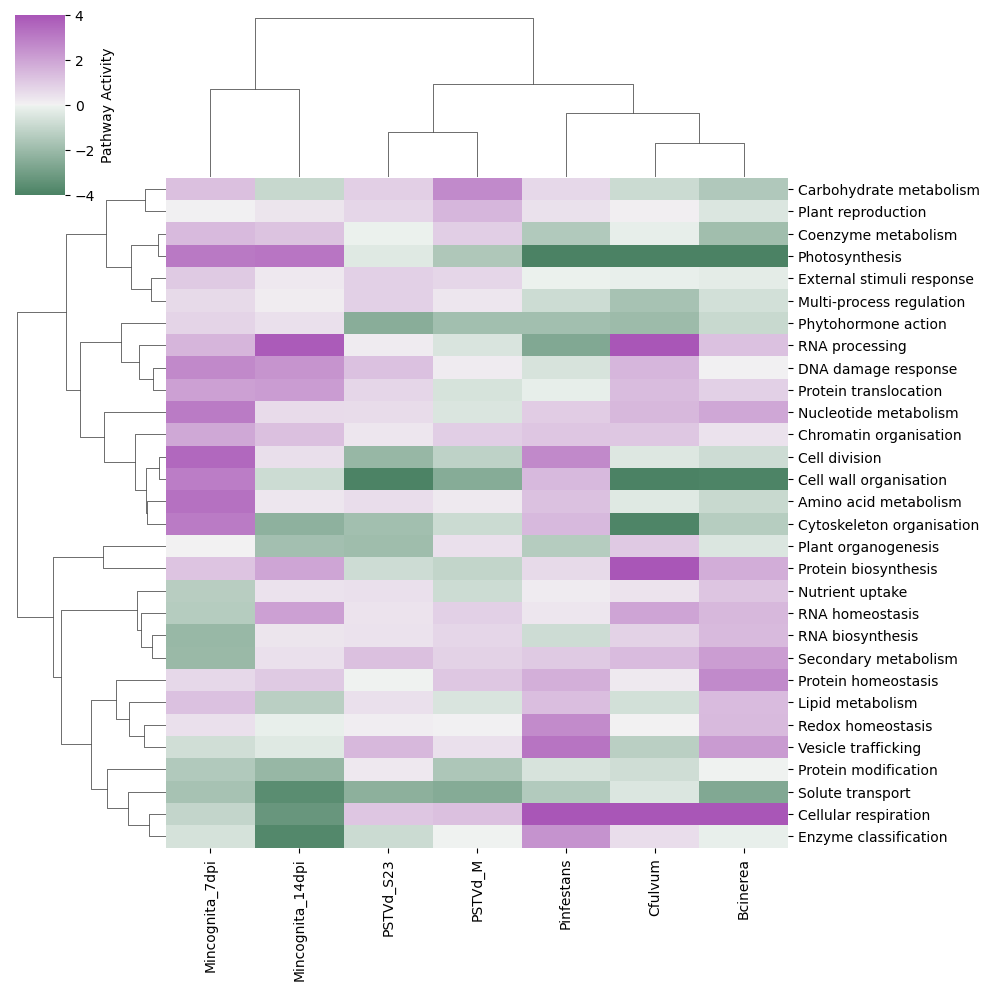

In [33]:
sns.clustermap(pathway_acts.T, 
               cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
               center=0,
               cbar_kws={'label': 'Pathway Activity'}, 
               vmin = -4, 
               vmax = 4,
               method='average',
               metric='correlation')   
plt.savefig('Plot/Supp_fig_Clustermap_activity_all_pathway.svg', format='svg')

In [34]:
pvals = pathway_pvals.T
acts = pathway_acts.T
significant_pvals = pvals[pvals[conditions].apply(lambda x: x <= 0.05, axis=1).any(axis=1)]
# new_column_names_pvals = {col: col + '_pval' for col in significant_pvals.columns}
# significant_pvals.rename(columns=new_column_names_pvals, inplace=True)
significant_acts = acts[acts.index.isin(significant_pvals.index)]
# new_column_names_acts = {col: col + '_acts' for col in significant_acts.columns}
# significant_acts.rename(columns=new_column_names_acts, inplace=True)

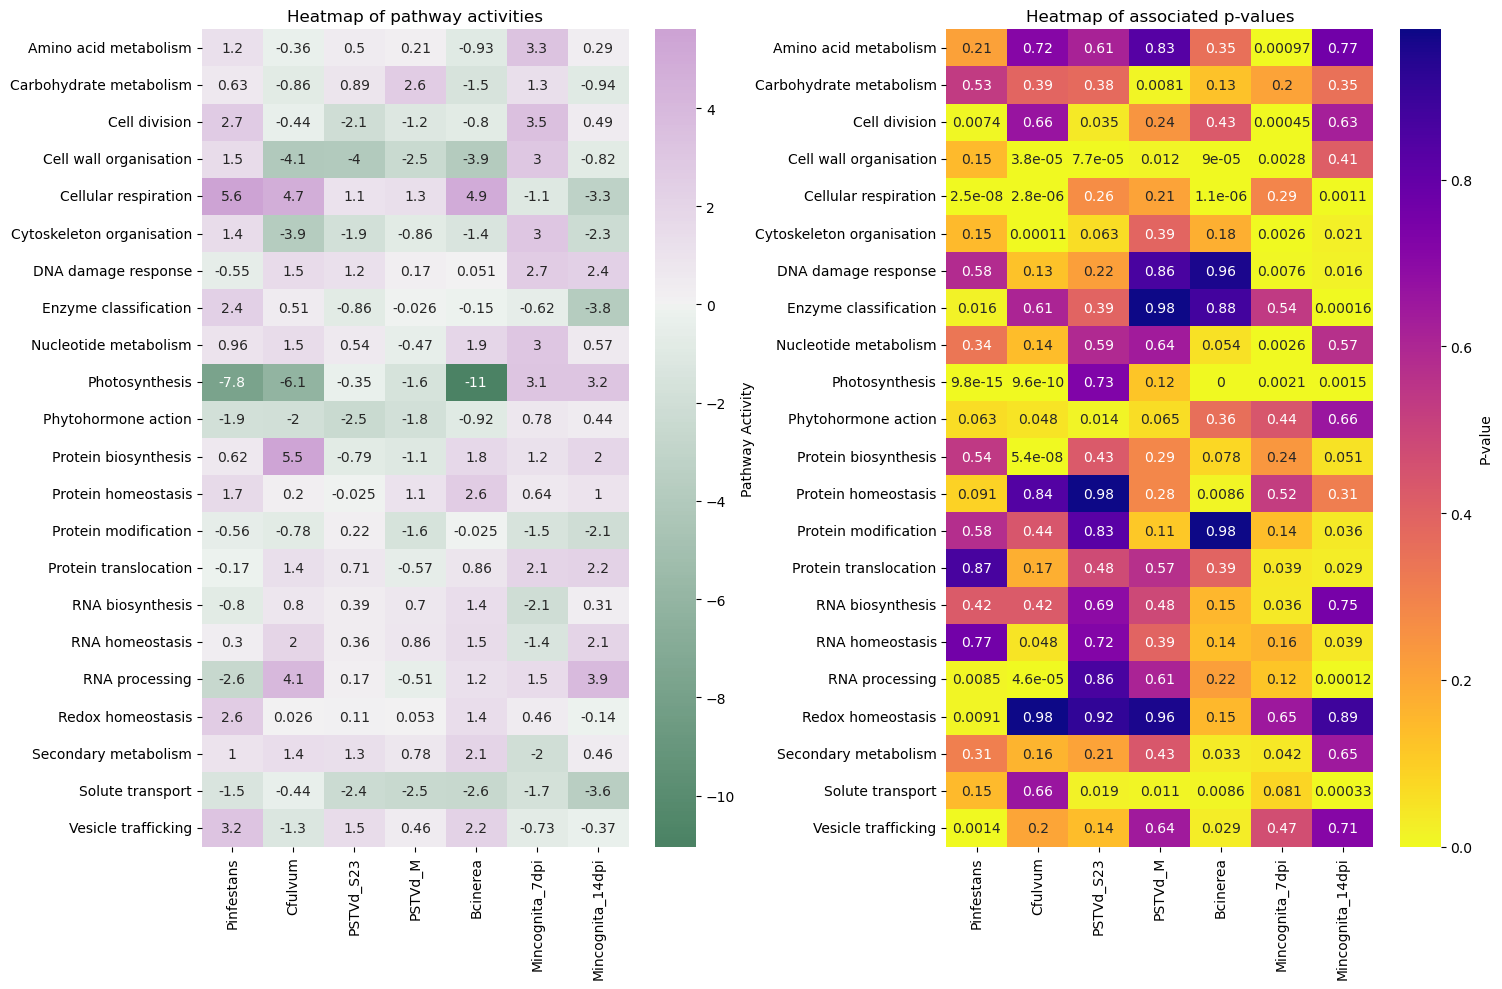

In [35]:
fig, axes = plt.subplots(1,2, figsize=(15,10), tight_layout=True)

axes[0].set_title('Heatmap of pathway activities')
sns.heatmap(significant_acts, cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), ax=axes[0], center=0, annot=True, cbar_kws={'label': 'Pathway Activity'})
axes[1].set_title('Heatmap of associated p-values')
sns.heatmap(significant_pvals, cmap='plasma_r', ax=axes[1], annot=True,cbar_kws={'label': 'P-value'})
plt.show()

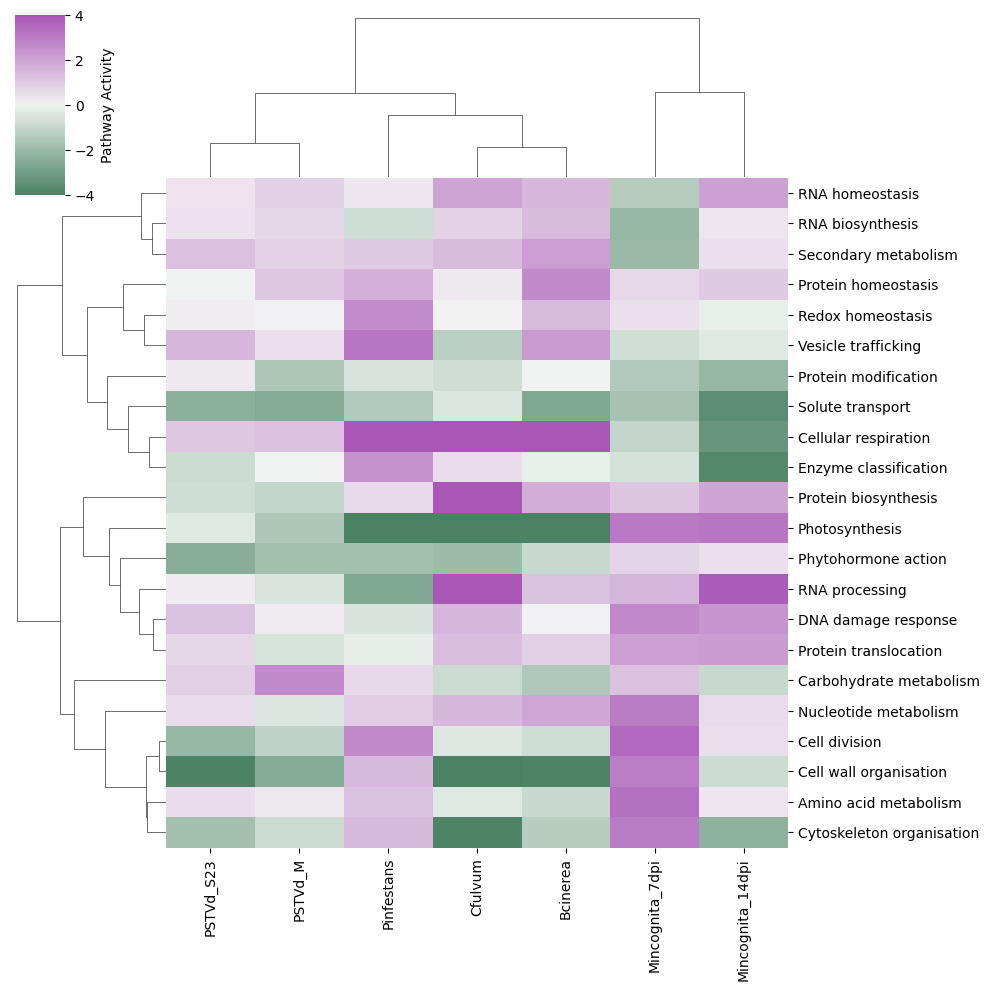

In [36]:
sns.clustermap(significant_acts, 
               cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
               center=0, 
               cbar_kws={'label': 'Pathway Activity'}, 
               vmin = -4, 
               vmax = 4,
               method='average',
               metric='correlation')
plt.savefig('Plot/Fig2_B_new.svg', format='svg')

In [39]:
significant_acts.iloc[:, 0:] = np.where(significant_pvals.iloc[:, 0:] <= 0.05, significant_acts.iloc[:, 0:], 0)
# significant_acts.iloc[:, 0:] = np.where(abs(significant_pvals.iloc[:, 0:]) <= 0.05, 0, significant_acts.iloc[:, 0:])
# significant_acts.to_csv('Results_pathway_activity_mercator.adj',sep='\t',index=True)

/tmp/ipykernel_32160/3082414728.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_acts.iloc[:, 0:] = np.where(significant_pvals.iloc[:, 0:] <= 0.05, significant_acts.iloc[:, 0:], 0)


<Axes: >

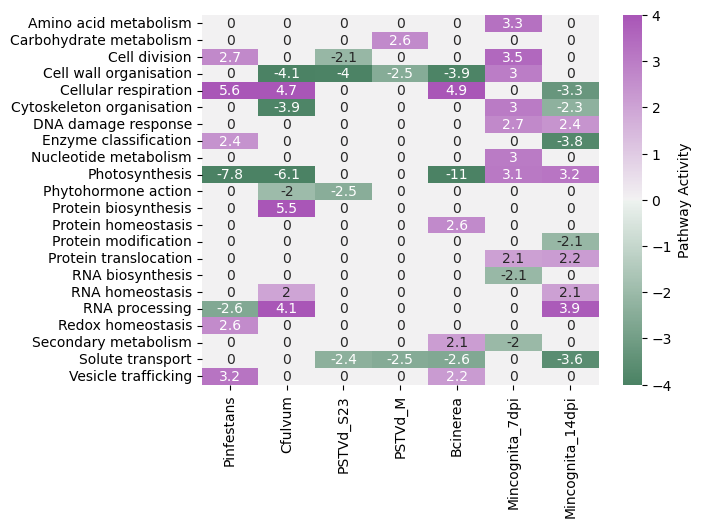

In [40]:
sns.heatmap(significant_acts, 
               cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), 
               center=0, 
               cbar_kws={'label': 'Pathway Activity'}, 
               vmin = -4, 
               vmax = 4,
               annot=True)   

In [ ]:
# import plotly.graph_objects as go
# import seaborn as sns
# import pandas as pd
# import matplotlib.cm as cm

# def sankey_pathway_activity(
#     df: pd.DataFrame,
#     title="Pathway activity Sankey",
#     vmax=4.0,
#     edge_color_mode="activity",  # "activity" or "condition"
# ):
#     """
#     Create a Sankey diagram of pathway activity with sorted flows and fixed layout.

#     Parameters
#     ----------
#     df : DataFrame
#         Pathways x Conditions matrix.
#     title : str
#         Plot title.
#     vmax : float
#         Scaling for activity colormap.
#     edge_color_mode : {"activity", "condition"}
#         How to color edges:
#           - "activity": diverging colormap by signed activity (default)
#           - "condition": each condition has its own color (classic Sankey style)
#     """

#     # --- compute flow counts ---
#     pathway_counts = (df != 0).sum(axis=1)
#     condition_counts = (df != 0).sum(axis=0)

#     # --- sort nodes by flow counts ---
#     sorted_conditions = condition_counts.sort_values(ascending=False).index.tolist()
#     sorted_pathways = pathway_counts.sort_values(ascending=False).index.tolist()

#     # --- node labels ---
#     cond_labels = [f"{c} ({condition_counts[c]})" for c in sorted_conditions]
#     path_labels = [f"{pw} ({pathway_counts[pw]})" for pw in sorted_pathways]
#     all_nodes = cond_labels + path_labels

#     node_idx = {name: i for i, name in enumerate(all_nodes)}

#     # --- color maps ---
#     cmap_activity = sns.diverging_palette(145, 300, s=60, as_cmap=True)
#     condition_colors = {
#     "Mincognita_14dpi": "saddlebrown",  
#     "Mincognita_7dpi": "saddlebrown",  
#     "PSTVd_M": "peru",   
#     "PSTVd_S23": "peru",  
#     "Pinfestans": "lawngreen",
#     "Bcinerea": "green",
#     "Cfulvum": "green",
#     }

#     # --- build all links ---
#     links = []
#     for cond in sorted_conditions:
#         for pw in sorted_pathways:
#             v = df.loc[pw, cond]
#             if v != 0:
#                 if edge_color_mode == "activity":
#                     t = (v / vmax + 1) / 2
#                     rgba = cmap_activity(t)
#                     color = f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"
#                 elif edge_color_mode == "condition":
#                     color = condition_colors.get(cond, "rgba(160,160,160,0.5)")
#                 else:
#                     raise ValueError("edge_color_mode must be 'activity' or 'condition'")

#                 links.append({
#                     "source": node_idx[f"{cond} ({condition_counts[cond]})"],
#                     "target": node_idx[f"{pw} ({pathway_counts[pw]})"],
#                     "value": 1,
#                     "raw": v,
#                     "color": color,
#                 })

#     links_df = pd.DataFrame(links)

#     # --- sort links (outgoing + incoming) ---
#     sorted_links = []
#     for cond in sorted_conditions:
#         cond_idx = node_idx[f"{cond} ({condition_counts[cond]})"]
#         cond_links = links_df[links_df.source == cond_idx].sort_values(by="raw")
#         sorted_links.append(cond_links)
#     for pw in sorted_pathways:
#         pw_idx = node_idx[f"{pw} ({pathway_counts[pw]})"]
#         pw_links = links_df[links_df.target == pw_idx].sort_values(by="raw")
#         sorted_links.append(pw_links)

#     links_df = pd.concat(sorted_links).drop_duplicates(subset=["source", "target"])

#     # --- extract lists for Plotly ---
#     sources = links_df["source"].tolist()
#     targets = links_df["target"].tolist()
#     values = links_df["value"].tolist()
#     colors = links_df["color"].tolist()
#     customdata = links_df["raw"].tolist()

#     # --- node colors ---
#     node_colors = ["rgba(160,160,160,0.9)"] * (len(sorted_conditions) + len(sorted_pathways))

#     # --- node hover info ---
#     node_hover = (
#         [f"%{{label}}<br>Outgoing pathways: {int(condition_counts[c])}" for c in sorted_conditions] +
#         [f"%{{label}}<br>Incoming conditions: {int(pathway_counts[pw])}" for pw in sorted_pathways]
#     )

#     # --- assign fixed positions ---
#     n_cond = len(sorted_conditions)
#     n_path = len(sorted_pathways)
#     x_pos, y_pos = [], []

#         # left column (conditions)
#     for i, _ in enumerate(sorted_conditions):
#         x_pos.append(0.001)
#         if n_cond > 1:
#             y_pos.append((i-0.005) / (n_cond - 1))# evenly spaced top→bottom
#         else:
#             y_pos.append(0.5)

#     # right column (pathways)
#     for i, _ in enumerate(sorted_pathways):
#         x_pos.append(0.999)
#         if n_path > 1:
#             y_pos.append((i-0.001) / (n_path - 1))
#         else:
#             y_pos.append(0.5)

#     # --- build figure ---
#     fig = go.Figure(data=[go.Sankey(
#         arrangement="fixed",
#         node=dict(
#             pad=20,
#             thickness=14,
#             line=dict(color="black", width=0.5),
#             label=all_nodes,
#             color=node_colors,
#             hovertemplate=node_hover,
#             x=x_pos,
#             y=y_pos,
#         ),
#         link=dict(
#             source=sources,
#             target=targets,
#             value=values,
#             color=colors,
#             customdata=customdata,
#             hovertemplate="From %{source.label} → %{target.label}<br>"
#                           "Activity: %{customdata}<extra></extra>"
#         ),
#     )])

#     fig.update_layout(
#         title=title,
#         font_size=12,
#         margin=dict(l=10, r=10, t=40, b=10),
#         width=1200,
#         height=max(800, len(sorted_pathways) * 20),
#     )

#     return fig


In [ ]:
# fig = sankey_pathway_activity(significant_acts, title="", edge_color_mode="condition")
# fig.write_image('Plot/Fig2_waterfall_pathway_condition_colored.svg', format='svg')
# fig.show()

/tmp/ipykernel_32160/2088936409.py:25: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



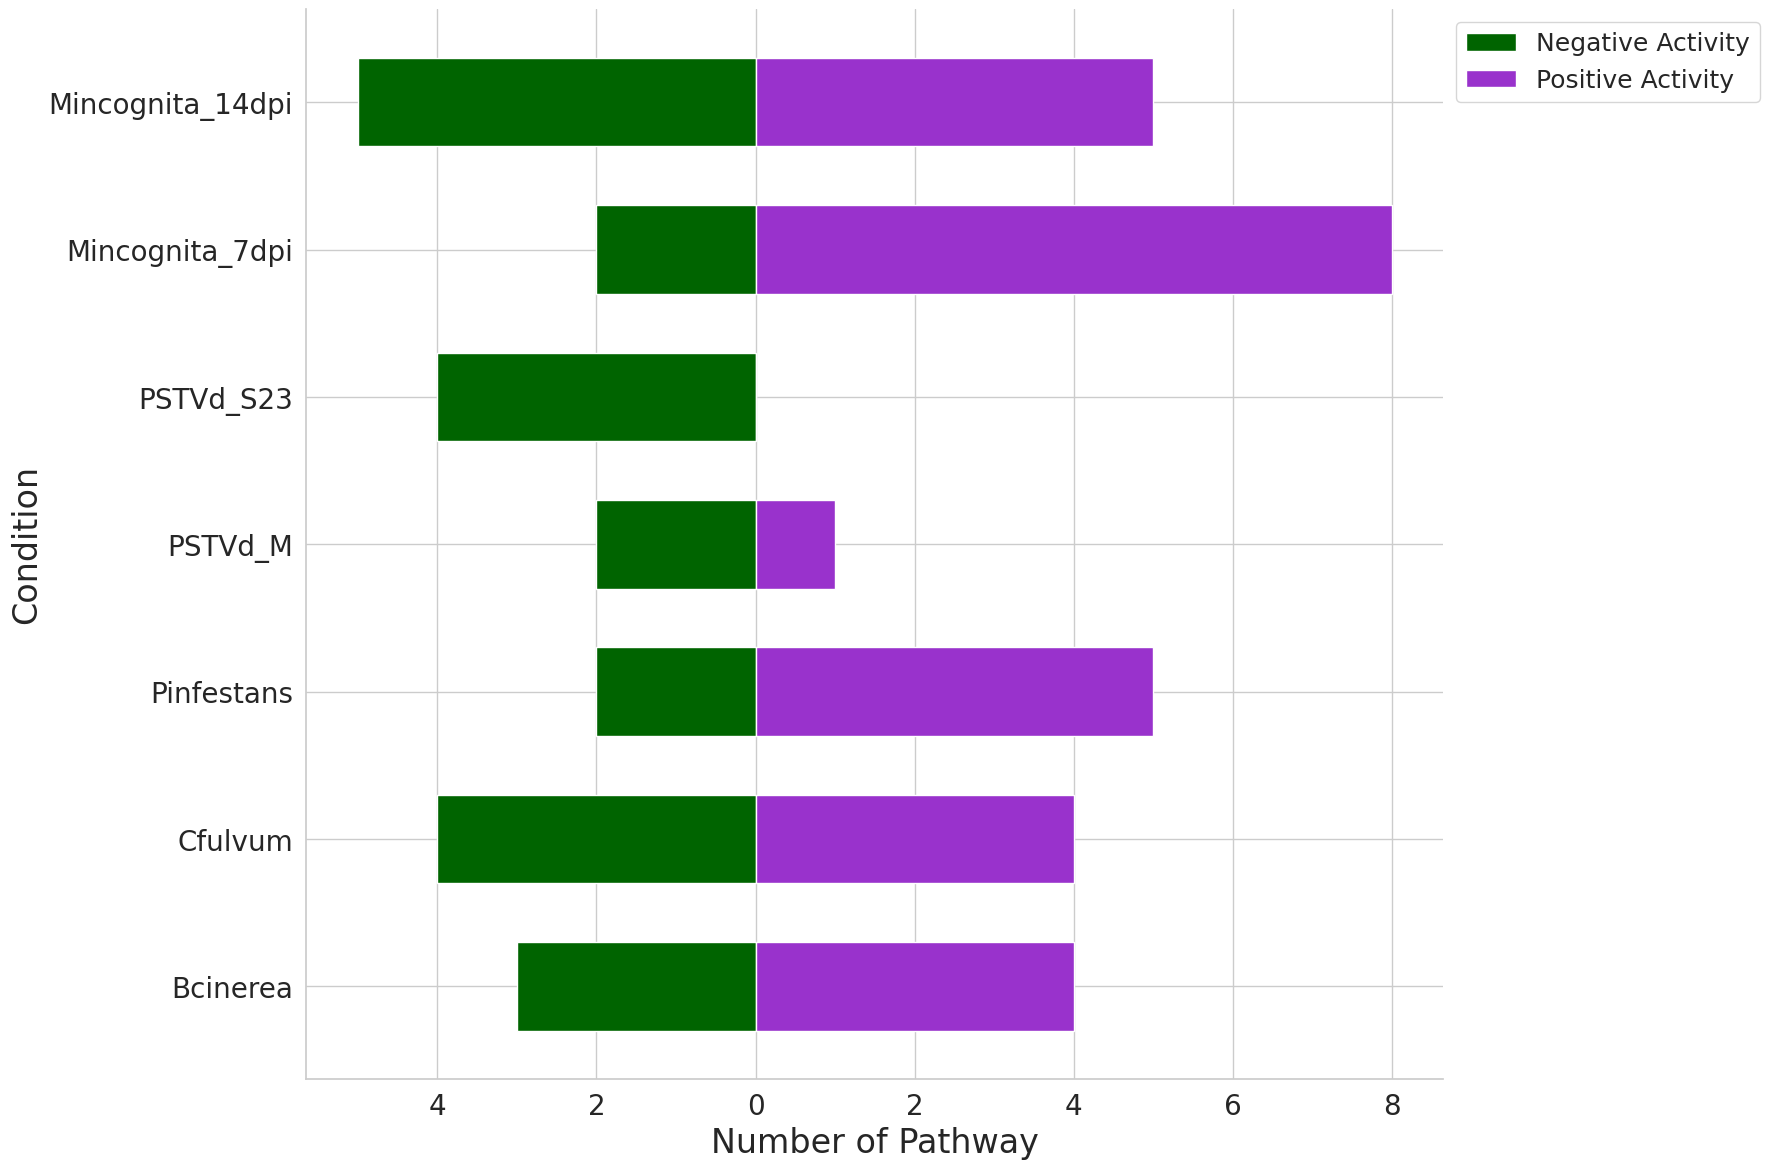

In [47]:
sns.set_theme(font_scale=1.4, style='whitegrid')
# Step 1: Convert pathway values to positive or negative counts
positive_counts = (significant_acts > 0).sum(axis=0)
negative_counts = (significant_acts < 0).sum(axis=0)

custom_order = ["Bcinerea","Cfulvum", "Pinfestans", "PSTVd_M", "PSTVd_S23", "Mincognita_7dpi", "Mincognita_14dpi"]

positive_counts = positive_counts.reindex(custom_order)
negative_counts = negative_counts.reindex(custom_order)

# Step 2: Plot butterfly plot with positive counts to the right and negative counts to the left
fig, ax = plt.subplots(figsize=(18, 12))

bar_width = 0.6  # Define the width of bars

# Plot negative values (displayed on the left side)
ax.barh(negative_counts.index, -negative_counts, color='darkgreen', label='Negative Activity', height=bar_width)

# Plot positive values (displayed on the right side)
ax.barh(positive_counts.index, positive_counts, color='darkorchid', label='Positive Activity', height=bar_width)

# Labels and title
ax.set_xlabel('Number of Pathway', fontsize=24)
xticks = ax.get_xticks()
ax.set_xticklabels([str(abs(int(x))) for x in xticks])
ax.set_ylabel('Condition', fontsize=24)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.tick_params(axis='both', labelsize=20)

# Add a legend
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=18, title_fontsize=20)

# Show the plot
plt.tight_layout()
plt.savefig('Plot/Fig2_D_new.svg', format='svg')
plt.show()

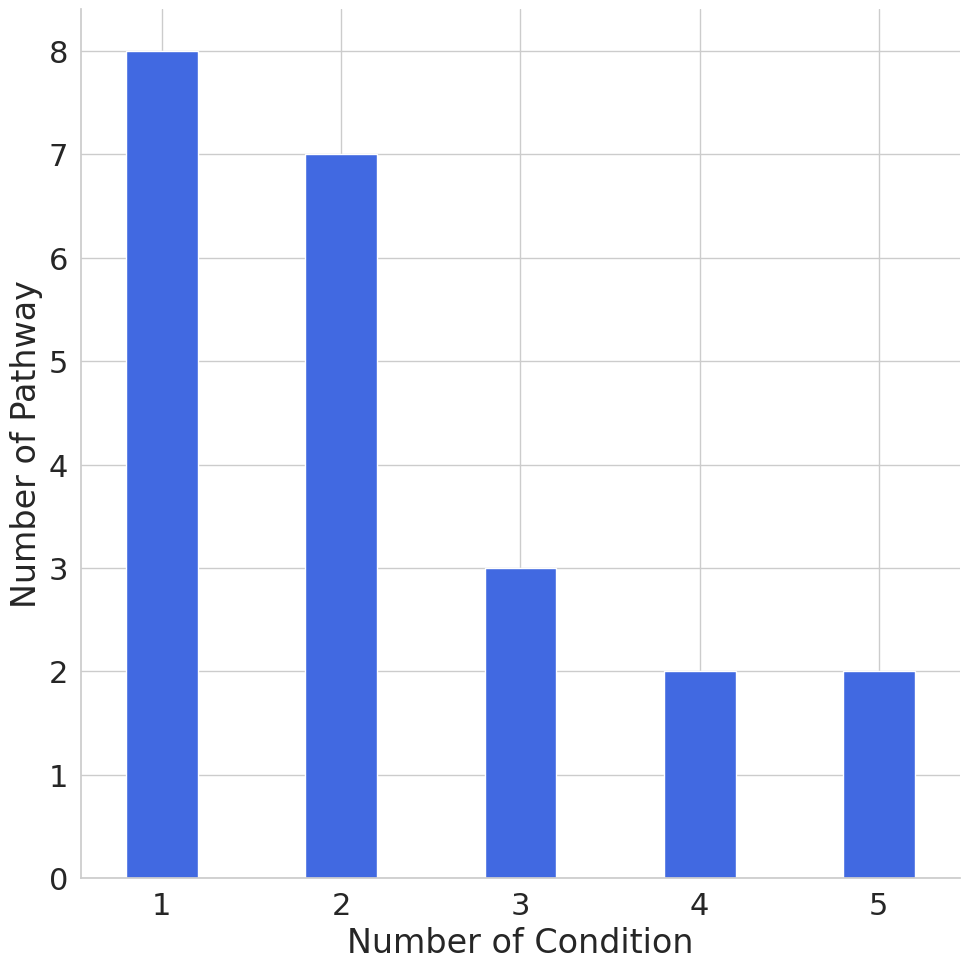

In [48]:
# Step 1: Define significance (p-value < 0.05)
significance = significant_pvals <= 0.05

# Step 2: Sum the significant pathways across all conditions
num_significant = significance.sum(axis=1)

# Step 3: Count how many pathways are significant in exactly 1, 2, ..., n conditions
significance_counts = num_significant.value_counts().sort_index()

# Step 4: Plot the results
fig, ax = plt.subplots(figsize=(10, 10))

significance_counts.plot(kind='bar', ax=ax, color='royalblue', width=0.4)

ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.tick_params(axis='both', labelsize=22)
ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
# Labels and title
ax.set_xlabel('Number of Condition', fontsize=24)
ax.set_ylabel('Number of Pathway', fontsize=24)

# Show the plot
plt.tight_layout()
plt.savefig('Plot/Fig2_C_new.svg', format='svg')
plt.show()

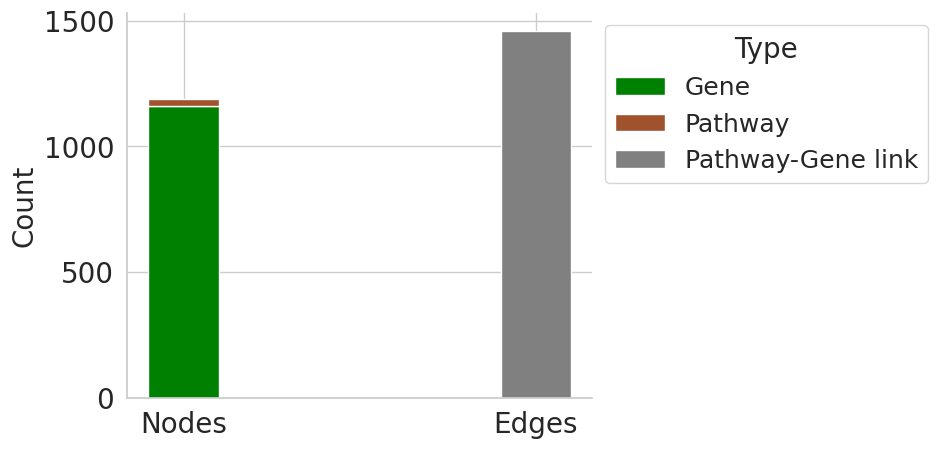

In [49]:
sns.set_theme(font_scale=1.4, style='whitegrid')
# Count nodes
pathway_nodes = set(network_pathway_mercator["source"])
target_nodes = set(network_pathway_mercator["target"])

node_counts = pd.DataFrame({
    "Category": "Nodes",
    "Type": ["Gene", "Pathway"],
    "Count": [len(target_nodes), len(pathway_nodes)]
})

# Count edges
edge_counts = pd.DataFrame({
    "Category": ["Edges"],
    "Type": ["Pathway-Gene link"],
    "Count": [len(network_pathway_mercator.drop_duplicates())]
})

# Combine for plotting
plot_df = pd.concat([node_counts, edge_counts])

colors = {'Pathway':'sienna', 'Gene':'green'}

# Define category positions
category_positions = {"Nodes": 0, "Edges": 0.5}  # Reduce spacing

fig, ax = plt.subplots(figsize=(6, 5))

bottoms = {"Nodes": 0, "Edges": 0}

for _, row in plot_df.iterrows():
    color = colors.get(row["Type"], "gray")
    ax.bar(
        category_positions[row["Category"]], row["Count"], label=row["Type"],
        bottom=bottoms[row["Category"]], color=color, width=0.1,  # Adjust width
    )
    bottoms[row["Category"]] += row["Count"]

# Set category labels at custom positions
ax.set_xticks([category_positions["Nodes"], category_positions["Edges"]])
ax.set_xticklabels(["Nodes", "Edges"], fontsize=20)
ax.set_ylabel("Count", fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)


# Ensure only unique legend entries
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), title="Type", loc="upper left", bbox_to_anchor=(1, 1), fontsize=18, title_fontsize=20)

plt.savefig('Plot/Pathway_network_description.svg', bbox_inches='tight', format='svg')
plt.show()

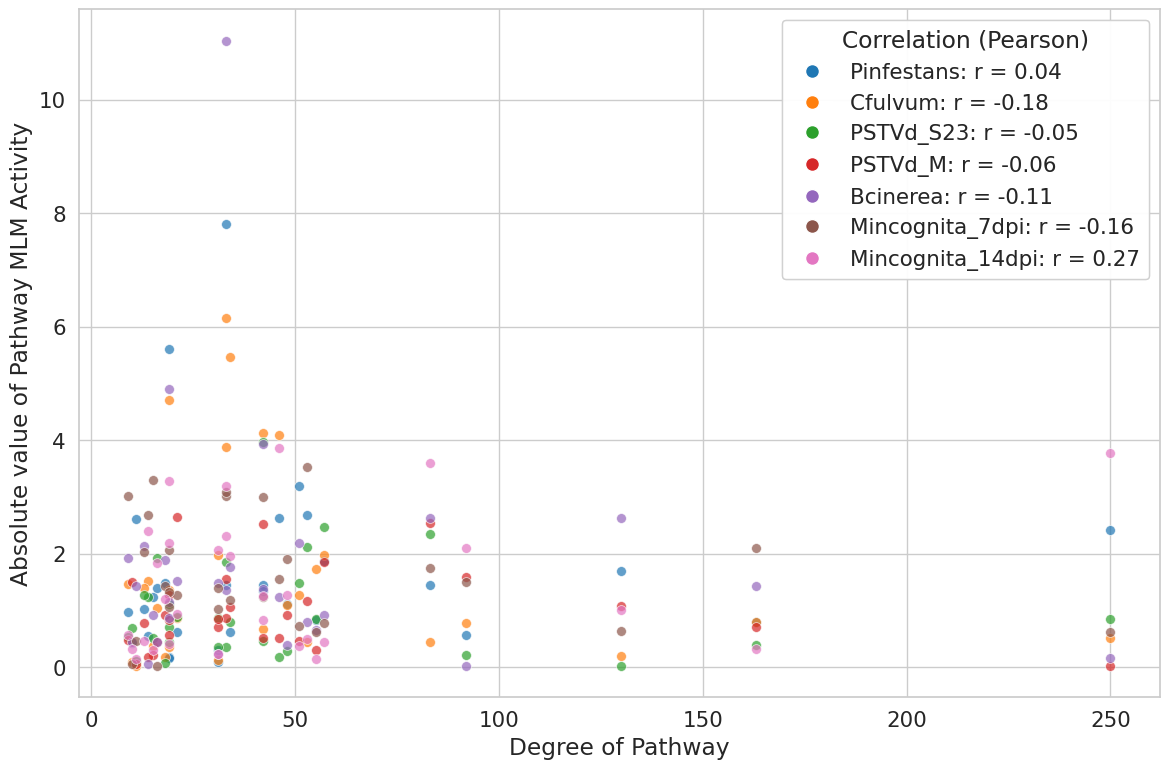

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
import pandas as pd

degree_pathway=network_pathway_mercator['source'].value_counts()
merged=pd.merge(degree_pathway, pathway_acts.T, left_index=True, right_index=True, how='right')
merged.reset_index(inplace=True)
long_df = pd.melt(merged, id_vars=['index','count'], var_name='Condition', value_name='Value')

plt.figure(figsize=(12, 8))

# Set color palette for conditions
palette = sns.color_palette("tab10", n_colors=len(long_df['Condition'].unique()))
conditions = long_df['Condition'].unique()

# Dictionary to store correlation info
corr_dict = {}

# Loop through each condition to plot and store Pearson correlation and p-value
for idx, condition in enumerate(conditions):
    # Filter data for the current condition
    subset = long_df[long_df['Condition'] == condition].copy()
    subset['Value'] = abs(subset['Value'])
    
    # Plot scatter and regression line
    sns.scatterplot(
        data=subset,
        x='count',
        y='Value',
        color=palette[idx],
        alpha=0.7,
        s=50,
        label=condition  # Add condition as label for the legend
    )
    
    # Calculate Pearson correlation coefficient and p-value
    if len(subset) > 1:  # Ensure there are at least two points to compute correlation
        corr, _ = pearsonr(subset['count'], subset['Value'])
    else:
        corr, _ = np.nan, "N/A"
    
    # Store in dictionary
    corr_dict[condition] = f"r = {corr:.2f}"

# Customize the plot

plt.xlabel('Degree of Pathway')
plt.ylabel('Absolute value of Pathway MLM Activity')
plt.grid(True)

# Create a second legend for correlation coefficients
corr_legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[idx], markersize=10, 
           label=f"{condition}: {corr_dict[condition]}")
    for idx, condition in enumerate(conditions)
]

# Add condition legend (default from seaborn)
# plt.legend(title="Condition", loc="upper left", bbox_to_anchor=(1, 1))  

# Add correlation legend
plt.gca().add_artist(plt.legend(handles=corr_legend_handles, title="Correlation (Pearson)", loc="upper right", bbox_to_anchor=(1, 1)))

# Adjust layout to make space for legends
plt.tight_layout()
plt.savefig('Plot/Correlation_degree_activity_pathway.svg', format='svg')